In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(base_dir, 'data', 'processed_data', 'House2_full.csv')
train_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.csv')
test_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.csv')
train_h5_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.h5')
test_h5_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.h5')
sys.path.append(base_dir)
train_npy_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.npy')
test_npy_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.npy')
test_visualize_dir = os.path.join(base_dir, 'data', 'test', 'test_house2_for_visualize.npy')

from src.tools.window_shifter import WindowShifter
from src.metrics.energy_base_metrics import MAE, NEP, Precision_energy_based, Recall_energy_based, F1_energy_based

In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset

class NILMDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.transform = transform
        npy_dir = data_dir.replace('.h5', '.npy')
        self.data_matrix = np.load(data_dir, mmap_mode='r')
        self.total_lines = self.data_matrix.shape[0]

    def __len__(self):
        return self.total_lines

    def __getitem__(self, idx):
        row = self.data_matrix[idx] 
        data = torch.tensor(row[:-9], dtype=torch.float32)
        label = torch.tensor(row[-9:], dtype=torch.float32)
        if self.transform:
            data = self.transform(data)
        data = data.unsqueeze(dim = 0)
        return data, label


In [5]:
train_set = np.load(train_npy_dir)
train_target = train_set[:,-9:]

In [7]:
train_target[:,8].shape

(5502997,)

In [9]:
sum(train_target[:,8]>10)

np.int64(32924)

In [10]:
5502997/32924


167.1424189041429

In [3]:
train_dataset = NILMDataset(train_npy_dir)
test_dataset = NILMDataset(test_npy_dir)
visualize_dataset = NILMDataset(test_visualize_dir)

In [4]:
batch_size = 256
train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
visualize_loader = DataLoader(dataset = visualize_dataset, batch_size = batch_size, shuffle = False, num_workers = 0)

In [61]:
vis = []
for i in visualize_loader:
    vis += i[1].reshape(-1).tolist()

In [62]:
len(vis)

90000

# Architecture: Encoder ###
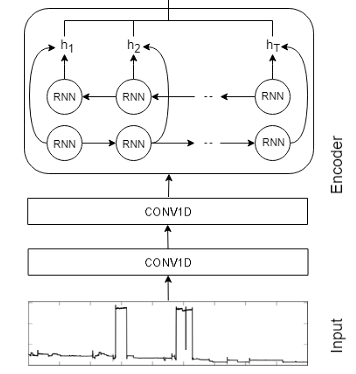

# Attention + Decoder ###
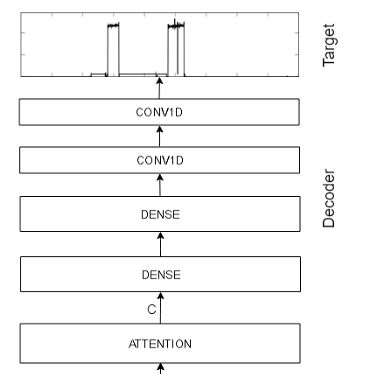

# Chú ý ###
Trong paper đang là kiến trúc s2s nhưng kiến trúc này có vấn đề chính là nó hoạt động giống nlp, yêu cầu 1 chuỗi đầu vào và đưa ra 1 chuỗi đầu ra vấn đề là nếu như có 2 chuỗi overlap với nhau thì kết quả công suất dự đoán của đoạn overlap chưa chắc giống nhau?. Vì thế nên biến đổi kiến trúc của phần decoder đi bằng cách bỏ đi 2 cái conv1d. Sau khi lấy được c từ lớp attention chỉ cần thêm 1 hoặc 2 lớp dense để lấy ra 1 output duy nhất

# Chú ý ###
Vì lstm yêu cầu đầu vào theo các bước thời gian nên cần shape là batch, length, channels, tưởng tượng mỗi bước thời gian là 1 điểm dữ liệu (có tất cả channels lớp, 1 điểm dữ liệu là xiên tất cả channels lớp đó)

# Cấu tạo của Attention ###
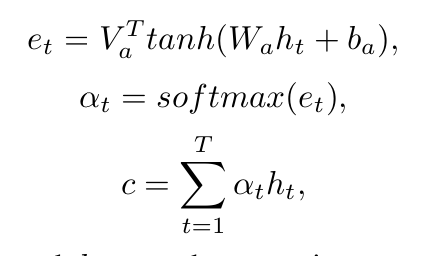

In [5]:
class S2PwAModel(nn.Module):
    def __init__(self, window_length = 300, in_channels = 1, filter_nums = 32, kernel_size = 3, hidden_dim = 64):
        super().__init__()
        self.window_length = window_length

        # Encoder
        self.conv1 = nn.Conv1d(in_channels, out_channels = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels = 32, out_channels  = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.bilstm = nn.LSTM(input_size = 32, hidden_size = hidden_dim, batch_first = True, bidirectional = True)
        bilstm_out_dim = hidden_dim * 2 # concat 2 vector của hidden state theo 2 chiều

        # Attention
        self.v_a = nn.Linear(hidden_dim, 1, bias = False)
        self.att_dense = nn.Linear(bilstm_out_dim, hidden_dim)
        self.att_softmax = nn.Softmax(dim = 1)
        
        # thay đổi kiến trúc cũ
        # đầu ra của attention là batch, bilstm_out_dim
        self.fc1 = nn.Linear(bilstm_out_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,1)
    
    def forward(self, x):
        # x sau khi lấy ra từ dataloader đang có dạng batch, channels, length
        x = self.conv1(x)
        x = self.conv2(x)
        # lstm mong đợi đầu vào dạng batch, length, channels
        x = x.permute(0,2,1) 
        h_t, _ = self.bilstm(x) 
        # h_t có dạng batch, length, hidden_dim*2
        energy = nn.Tanh()(self.att_dense(h_t)) # batch, length, hidden_dim
        score = self.v_a(energy) # batch, length, 1 (có thể hiểu là có l hidden state mối hidden state có 1 trọng số riêng để thể hiện sự đóng góp)
        alpha_t = self.att_softmax(score) # batch, length, 1
        c = (h_t * alpha_t).sum(dim = 1) # batch, hidden_dim * 2
        x = self.fc1(c) # batch, 64
        x = self.relu(x) 
        x = self.fc2(x) # batch, 1
        return x

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Tính Mean và Std của Dataset

In [7]:
df = pd.read_csv(data_dir)
app_cols = ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']
invalid_mask_train = df['Aggregate'] <= df[app_cols].sum(axis=1)
df.loc[invalid_mask_train, app_cols] = np.nan
df.loc[invalid_mask_train, 'Aggregate'] = np.nan
df[app_cols] = df[app_cols].ffill()
df[app_cols] = df[app_cols].fillna(0)
df['Aggregate'] = df['Aggregate'].ffill()
df['Aggregate'] = df['Aggregate'].fillna(0)
df_time_to_date = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')
df['dom'] = df_time_to_date.dt.day

In [8]:
train = df[((df['dom']-1)//7+1)%2==0]

In [9]:
train_mean = train['Aggregate'].mean()
train_std = train['Aggregate'].std()

In [10]:
train_mean, train_std

(np.float64(494.62987145211497), np.float64(1088.939294395772))

# Test model cho app1 trước ###

In [ ]:
model_save_dir = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app1.pth')

In [ ]:
model_app1 = S2PwAModel().to(device)
# model_app1.load_state_dict(torch.load(model_save_dir, weights_only=True))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_app1.parameters(), lr = 1e-4)

epochs  = 30
min_eval_loss = np.inf

for epoch in range(epochs):
    model_app1.train()
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data = (data - train_mean)/train_std
        target = target[:,[0]]
        data, target = data.to(device).to(torch.float), target.to(device).to(torch.float)
        optimizer.zero_grad()
        output = model_app1(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss/(batch_idx + 1)
    print(f'EPOCH: {epoch+1}, average train loss: {avg_train_loss}')

    model_app1.eval()
    eval_loss = 0.0
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader)):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[0]].to(device)
            pred = model_app1(data_eval)
            eval_loss += criterion(pred, target_eval).item()
            if batch_idx == 1000:
                break
        avg_eval_loss = eval_loss/(batch_idx + 1)
        if avg_eval_loss < min_eval_loss:
            min_eval_loss = avg_eval_loss
            torch.save(model_app1.state_dict(), model_save_dir)
        print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss}')

100%|██████████| 10287/10287 [04:01<00:00, 42.63it/s]


EPOCH: 1, average train loss: 1273.7191736683549


  9%|▉         | 1000/11328 [00:12<02:04, 82.94it/s]


EPOCH: 1, average eval loss: 783.8926200732853


100%|██████████| 10287/10287 [03:38<00:00, 47.02it/s]


...

EPOCH: 29, average eval loss: 652.5857058148013


100%|██████████| 10287/10287 [03:14<00:00, 52.94it/s]


EPOCH: 30, average train loss: 615.9490383144856


  9%|▉         | 1000/11328 [00:10<01:46, 96.75it/s]

EPOCH: 30, average eval loss: 663.9845978845838


In [ ]:
model_app1.load_state_dict(torch.load(model_save_dir, weights_only=True))
model_app1.eval()
all_outputs = []
all_targets = []

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(tqdm(test_loader)):
        # Chuẩn hóa dữ liệu ngay trong batch
        data = (data - train_mean) / train_std
        
        data = data.to(device).to(torch.float)
        target = target[:,[0]].to(device).to(torch.float)
        
        output = model_app1(data)
        
        all_outputs.append(output.cpu().detach())
        all_targets.append(target.cpu().detach())
        
        if batch_idx == 1000:
            break

output = torch.cat(all_outputs, dim=0)
test_target = torch.cat(all_targets, dim=0)

ground_truth = test_target.numpy()
pred = output.numpy()
test_target.shape

  9%|▉         | 1000/11328 [00:10<01:46, 97.32it/s]


torch.Size([256256, 1])

In [ ]:
ground_truth = test_target.cpu().detach().numpy()
pred = output.cpu().detach().numpy()

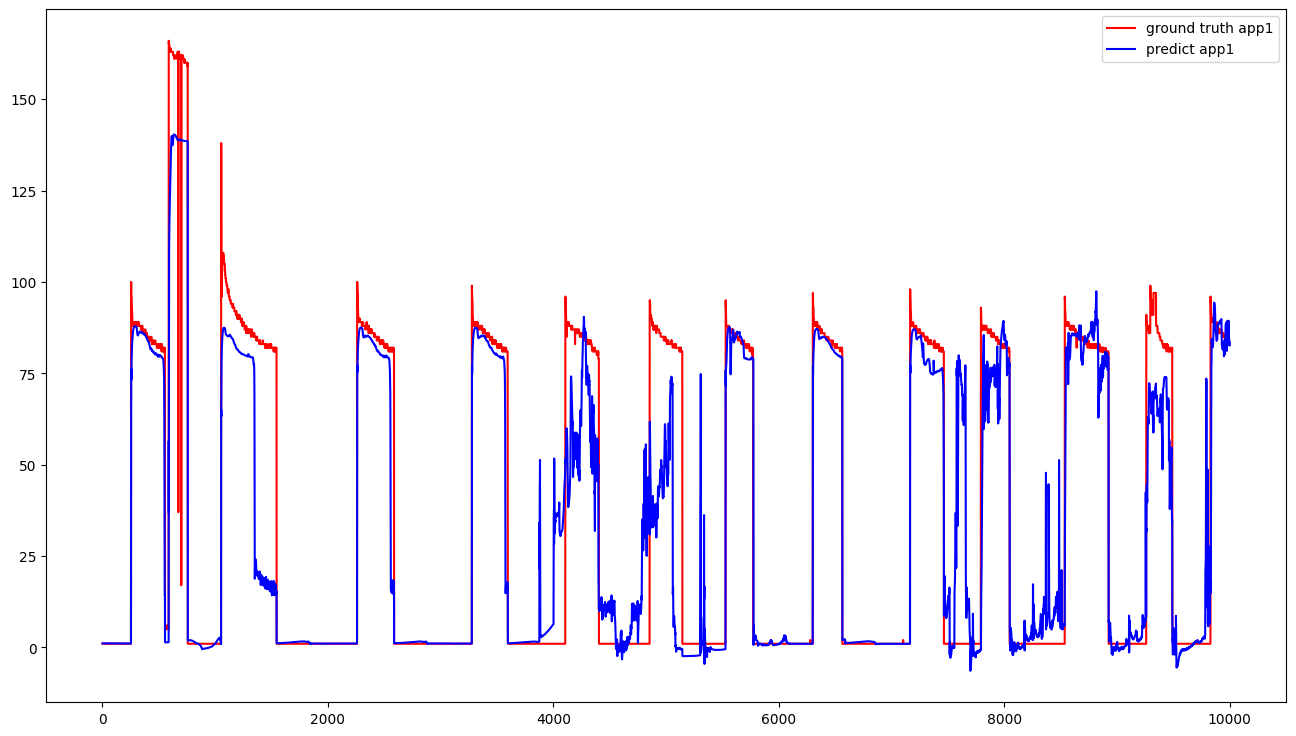

In [ ]:
plt.figure(figsize = (16,9))
plt.plot(ground_truth.reshape(-1)[10000:20000], color = 'r', label = 'ground truth app1')
plt.plot(pred.reshape(-1)[10000:20000], color = 'b', label = 'predict app1')
plt.legend(loc = 'best')
plt.show()

In [10]:
def Precision_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_predict.sum(axis = 0) 
    numerator = np.minimum(y_predict, y_target).sum(axis = 0) 
    return (numerator + alpha) / (denominator + alpha)
def Recall_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)
def F1_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    p_denominator = y_predict.sum(axis = 0)
    r_denominator = y_target.sum(axis = 0)
    precision = (numerator + alpha) / (p_denominator + alpha)
    recall = (numerator + alpha) / (r_denominator + alpha)
    return 2 * precision * recall / (precision + recall)
def NEP_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.abs(y_target - y_predict).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

# Tiếp tục test cho các app còn lại

In [11]:
model_save_dir1 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app1.pth')
model_save_dir1_upgrade = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app1_upgrade.pth')
model_save_dir2 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app2.pth')
model_save_dir3 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app3.pth')
model_save_dir4 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app4.pth')
model_save_dir5 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app5.pth')
model_save_dir6 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app6.pth')
model_save_dir7 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app7.pth')
model_save_dir8 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app8.pth')
model_save_dir9 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app9.pth')

Đã thử qua nhiều phương pháp nhưng điểm số của 1 số thiết bị không lên nổi, khả năng là nên bổ sung thêm vào tập train từ 1 số sample ở tập test đối với các thiết bị có thời gian off nhiều

In [12]:
app = ['Fridge-Freezer', 'Washing Machine', 'Dishwasher', 'Television',
'Microwave', 'Toaster', 'Hi-Fi', 'Kettle', 'Oven Extractor Fan'
]

Tạo loss function mới để chú ý nhiều hơn vào các điểm đang bật

In [13]:
import torch
import torch.nn as nn

class WeightedMAELoss(nn.Module):
    def __init__(self, weight_factor=15.0, weight_factor_off = 1.0, threshold_watt=10.0, appliance_min=0.0, appliance_max=1.0):
        super(WeightedMAELoss, self).__init__()
        self.weight_factor = weight_factor
        self.threshold_watt = threshold_watt
        self.appliance_min = appliance_min
        self.appliance_max = appliance_max
        self.weight_factor_off = weight_factor_off

    def forward(self, pred, target_scaled):
        loss = torch.abs(pred - target_scaled)
        target_watt = target_scaled * (self.appliance_max - self.appliance_min) + self.appliance_min   # chuẩn hóa ngược để xem giá trị nguyên bản có lớn hơn 0 ko
        weights = torch.where(target_watt > self.threshold_watt, self.weight_factor, self.weight_factor_off)     # tạo ra 1 tensor cùng shape nếu tmdk thì thay bởi giá trị đầu tiên ko thì 1.0
        weighted_loss = loss * weights
        return weighted_loss.mean()

In [14]:
app_min = np.array([0., 0., 0., 0., 0., 0., 0., 0., 0.])
app_max = np.array([1639., 2555., 2480.,  512., 1242., 1024., 1536., 2939.,  384.])

In [15]:
def trainer(epochs, save_dir, app_num, device = device, lr = 1e-4, weight_factor=15.0, weight_factor_off = 1.0, threshold_watt = 15.0):
    model = S2PwAModel().to(device)
    if os.path.exists(save_dir):
        model.load_state_dict(torch.load(save_dir, weights_only=True))
    criterion = WeightedMAELoss(appliance_min = app_min[app_num - 1], appliance_max = app_max[app_num - 1], weight_factor = weight_factor, threshold_watt = threshold_watt, weight_factor_off = weight_factor_off)                   # chuyển sang dùng mae
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    min_eval_loss = np.inf
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
            data = (data - train_mean)/train_std
            target = target[:,[app_num - 1]]
            target = (target - app_min[app_num - 1])/(app_max[app_num - 1] - app_min[app_num - 1])
            data, target = data.to(device).to(torch.float), target.to(device).to(torch.float)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target) 
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss/(batch_idx + 1)
        print(f'EPOCH: {epoch+1}, average train loss: {avg_train_loss}')

        model.eval()
        eval_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader)):
                data_eval = (data_eval - train_mean)/train_std
                data_eval = data_eval.to(device)
                target_eval = target_eval[:,[app_num - 1]].to(device)
                target_eval = (target_eval - app_min[app_num - 1])/(app_max[app_num - 1] - app_min[app_num - 1])
                pred = model(data_eval)
                eval_loss += criterion(pred, target_eval).item()
            avg_eval_loss = eval_loss/(batch_idx + 1)
            if avg_eval_loss < min_eval_loss:
                min_eval_loss = avg_eval_loss
                torch.save(model.state_dict(), save_dir)
            print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss}')
    print(f'Done training model for appliance {app_num}')

In [16]:
def tester(save_dir, app_num, test_batch_size = -1, device = device):
    model = S2PwAModel().to(device)
    model.load_state_dict(torch.load(save_dir, weights_only=True))
    model.eval()
    pred = []
    ground_truth = []
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(test_loader):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[app_num - 1]].to(device)
            ground_truth += (target_eval.detach().cpu().reshape(-1).tolist())
            pred += (model(data_eval) * (app_max[app_num - 1] - app_min[app_num - 1]) + app_min[app_num - 1]).clamp(0).detach().cpu().reshape(-1).tolist()     # cần chuẩn hóa ngược lại 
            if batch_idx == test_batch_size:
                break
    plt.figure(figsize = (16,9))
    plt.plot(ground_truth, color = 'r', label = f'ground truth of app{app_num}')
    plt.plot(pred, color = 'b', label = f'prediction of app{app_num}')
    plt.legend()
    plt.show()
    print(f'f1_energy_base: {F1_energy_based_fixed(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    print(f'mae: {MAE(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    ANE = np.abs((np.array(pred).sum() - np.array(ground_truth).sum()))/np.array(pred).sum()
    print(f'ane: {ANE}')


In [17]:
def visualize(save_dir, app_num, test_batch_size = -1, device = device):
    model = S2PwAModel().to(device)
    model.load_state_dict(torch.load(save_dir, weights_only=True))
    model.eval()
    pred = []
    ground_truth = []
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(visualize_loader):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[app_num - 1]].to(device)
            ground_truth += (target_eval.detach().cpu().reshape(-1).tolist())
            pred += (model(data_eval) * (app_max[app_num - 1] - app_min[app_num - 1]) + app_min[app_num - 1]).clamp(0).detach().cpu().reshape(-1).tolist()     # cần chuẩn hóa ngược lại 
            if batch_idx == test_batch_size:
                break
    plt.figure(figsize = (16,9))
    plt.plot(pred, color = 'b', label = f'prediction of app{app_num}')
    plt.plot(ground_truth, color = 'r', label = f'ground truth of app{app_num}')
    plt.legend()
    plt.show()
    print(f'f1_energy_base: {F1_energy_based_fixed(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    print(f'mae: {MAE(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    ANE = np.abs((np.array(pred).sum() - np.array(ground_truth).sum()))/np.array(pred).sum()
    print(f'ane: {ANE}')


In [18]:
trainer(epochs = 20, save_dir = model_save_dir1_upgrade, app_num = 1)

100%|██████████| 10287/10287 [03:57<00:00, 43.31it/s]


EPOCH: 1, average train loss: 1.5275464807224655


100%|██████████| 274/274 [00:03<00:00, 72.71it/s]


EPOCH: 1, average eval loss: 1.219302055391952


100%|██████████| 10287/10287 [04:11<00:00, 40.90it/s]


...

EPOCH: 19, average eval loss: 0.9515123471726467


100%|██████████| 10287/10287 [03:44<00:00, 45.90it/s]


EPOCH: 20, average train loss: 0.8782076156497454


100%|██████████| 274/274 [00:02<00:00, 105.98it/s]

EPOCH: 20, average eval loss: 0.9474765801951833
Done training model for appliance 1


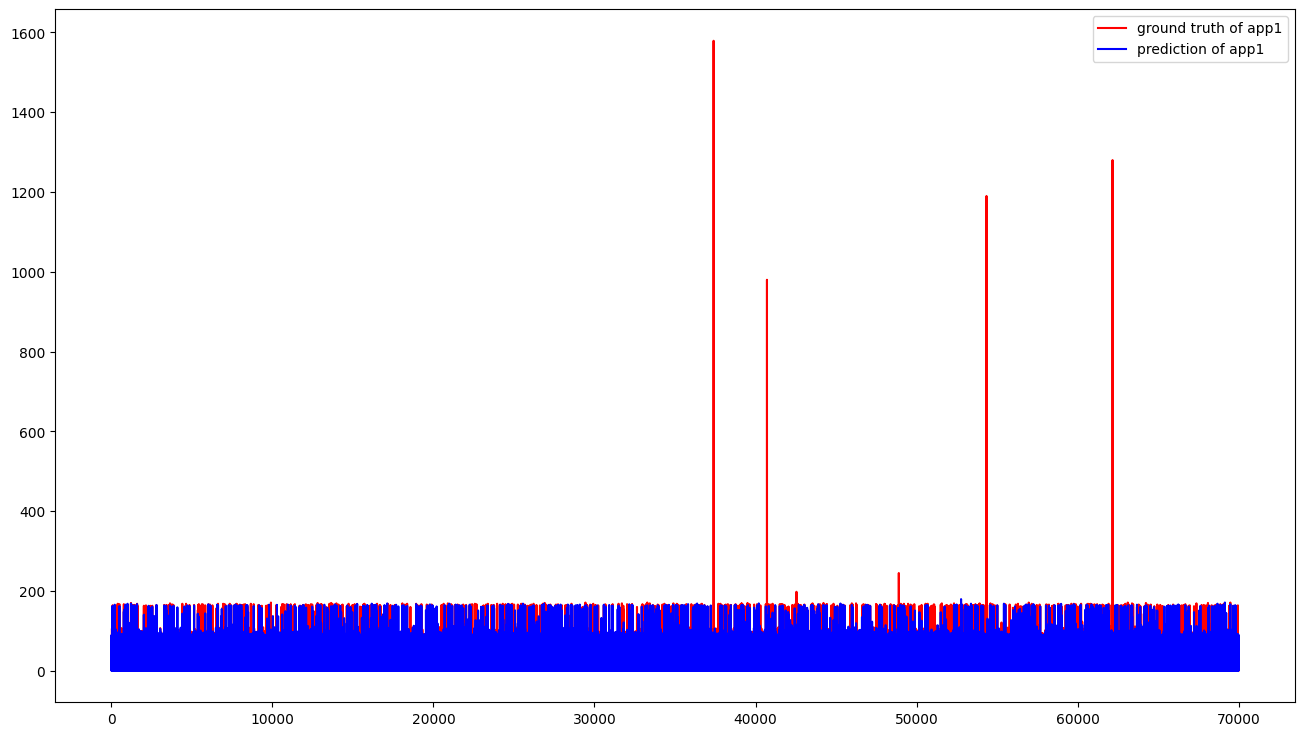

f1_energy_base: [0.77726652]
mae: [19.60087744]
ane: 0.3274785187585087


In [21]:
tester(save_dir = model_save_dir1_upgrade, app_num = 1)

In [97]:
trainer(epochs = 20, save_dir = model_save_dir2, app_num = 2)

100%|██████████| 10287/10287 [03:13<00:00, 53.12it/s]


EPOCH: 1, average train loss: 0.584644274101135


100%|██████████| 274/274 [00:02<00:00, 114.49it/s]


EPOCH: 1, average eval loss: 0.8583541800723459


100%|██████████| 10287/10287 [03:14<00:00, 52.80it/s]


...

EPOCH: 19, average eval loss: 0.7864751255098921


100%|██████████| 10287/10287 [03:14<00:00, 52.87it/s]


EPOCH: 20, average train loss: 0.35700850090013947


100%|██████████| 274/274 [00:02<00:00, 116.68it/s]

EPOCH: 20, average eval loss: 0.8278054163458138
Done training model for appliance 2


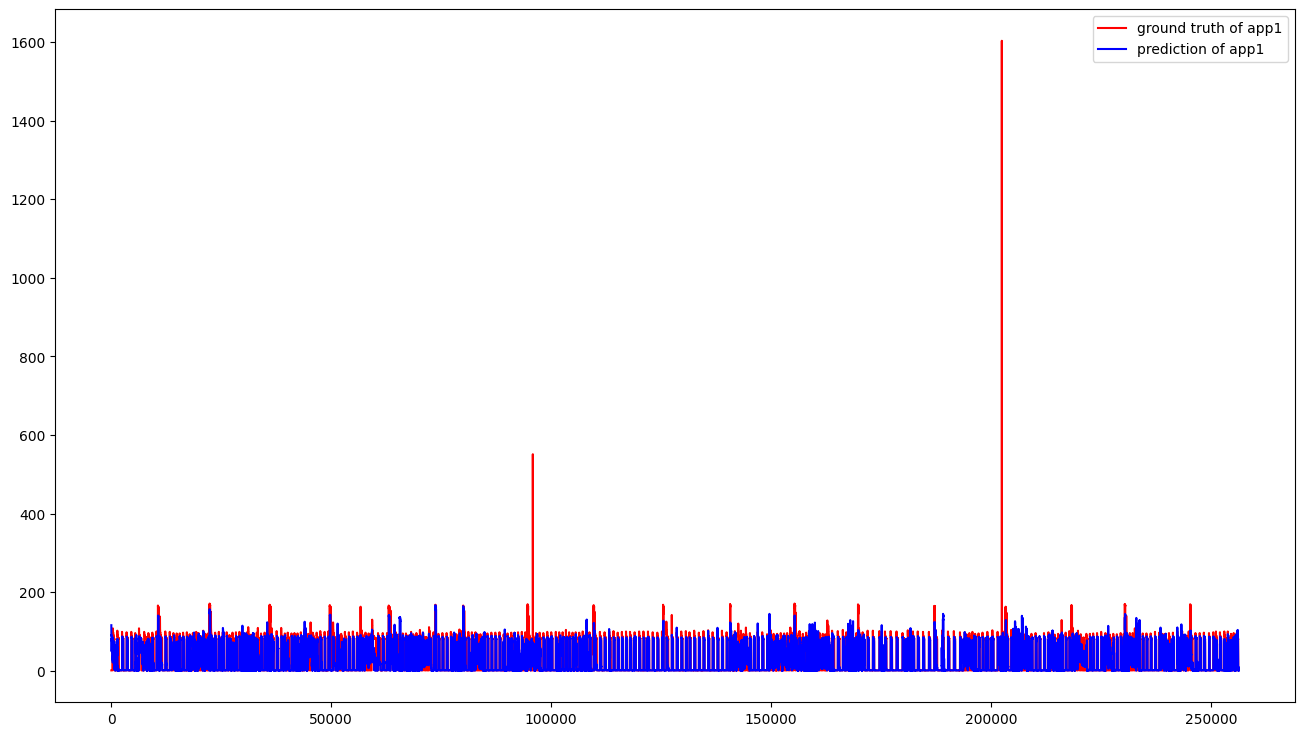

[0.79964453]


In [ ]:
tester(save_dir = model_save_dir1, app_num = 1, test_batch_size = 1000)       # model của app1 vẫn là chưa chuẩn hóa target

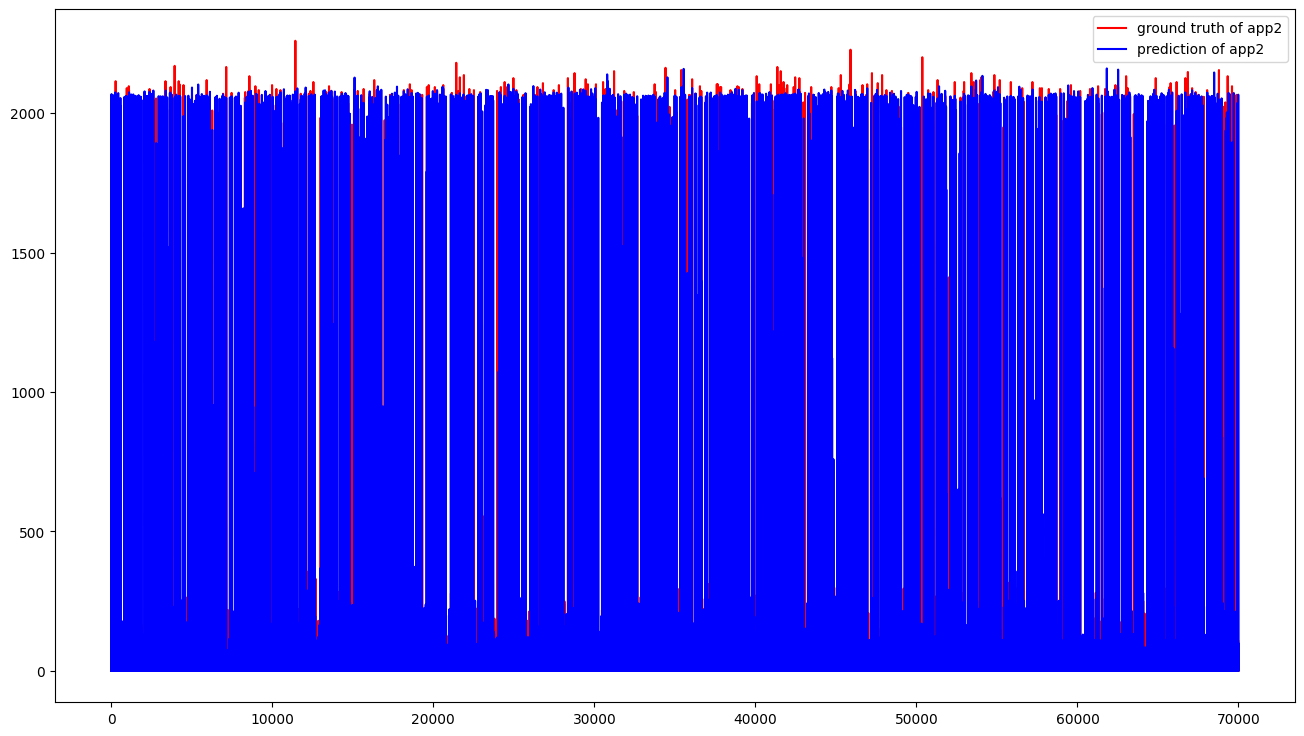

f1_energy_base: [0.41014567]
mae: [35.65450044]
ane: 0.5737168391774019


In [114]:
tester(save_dir = model_save_dir2, app_num = 2)

In [101]:
trainer(epochs = 20, save_dir = model_save_dir3, app_num = 3)
trainer(epochs = 20, save_dir = model_save_dir4, app_num = 4)

100%|██████████| 10287/10287 [03:17<00:00, 52.07it/s]


EPOCH: 1, average train loss: 1.2532940652644053


100%|██████████| 274/274 [00:02<00:00, 108.41it/s]


EPOCH: 1, average eval loss: 0.8199721791774687


100%|██████████| 10287/10287 [03:18<00:00, 51.88it/s]


...

EPOCH: 19, average eval loss: 2.219604439979052


100%|██████████| 10287/10287 [03:19<00:00, 51.53it/s]


EPOCH: 20, average train loss: 1.651791079620051


100%|██████████| 274/274 [00:02<00:00, 107.96it/s]

EPOCH: 20, average eval loss: 2.1332481407771144
Done training model for appliance 4


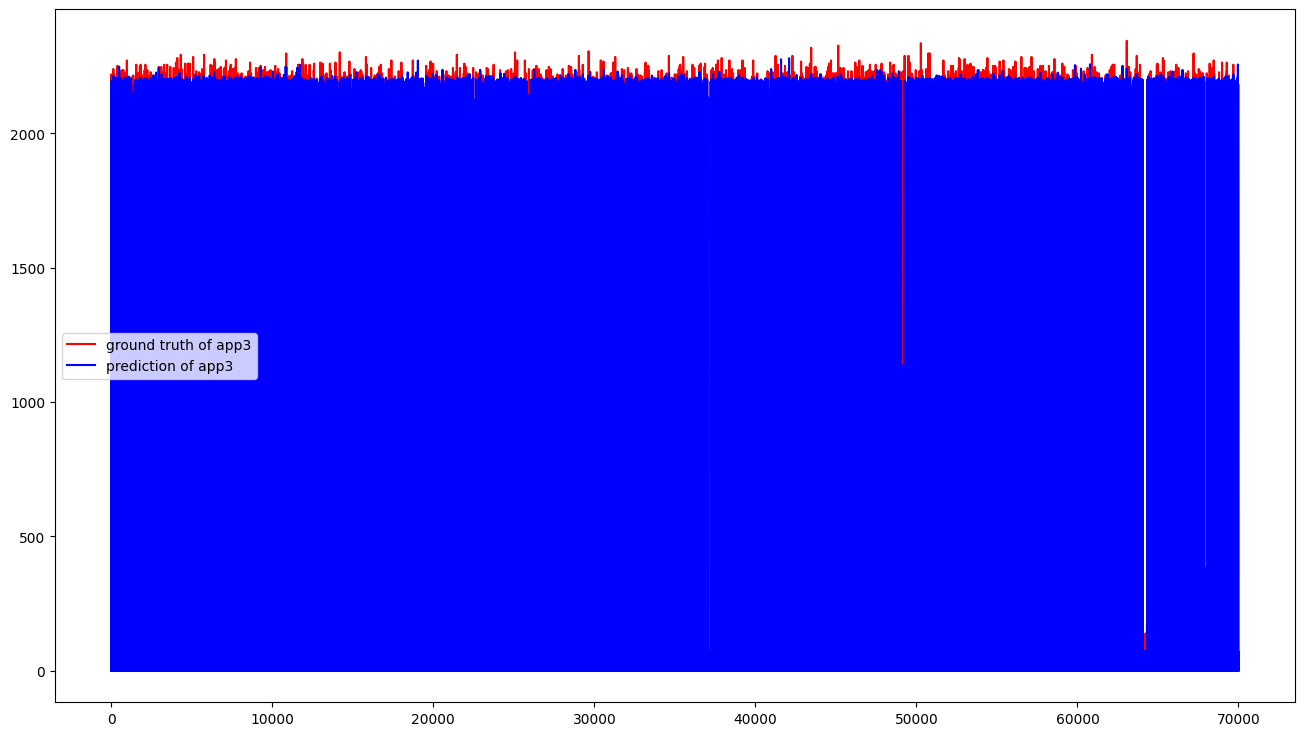

f1_energy_base: [0.77369451]
mae: [33.73949792]
ane: 0.30176261327695975


In [115]:
tester(save_dir =  model_save_dir3, app_num = 3) # sau chuẩn hóa và weighted loss

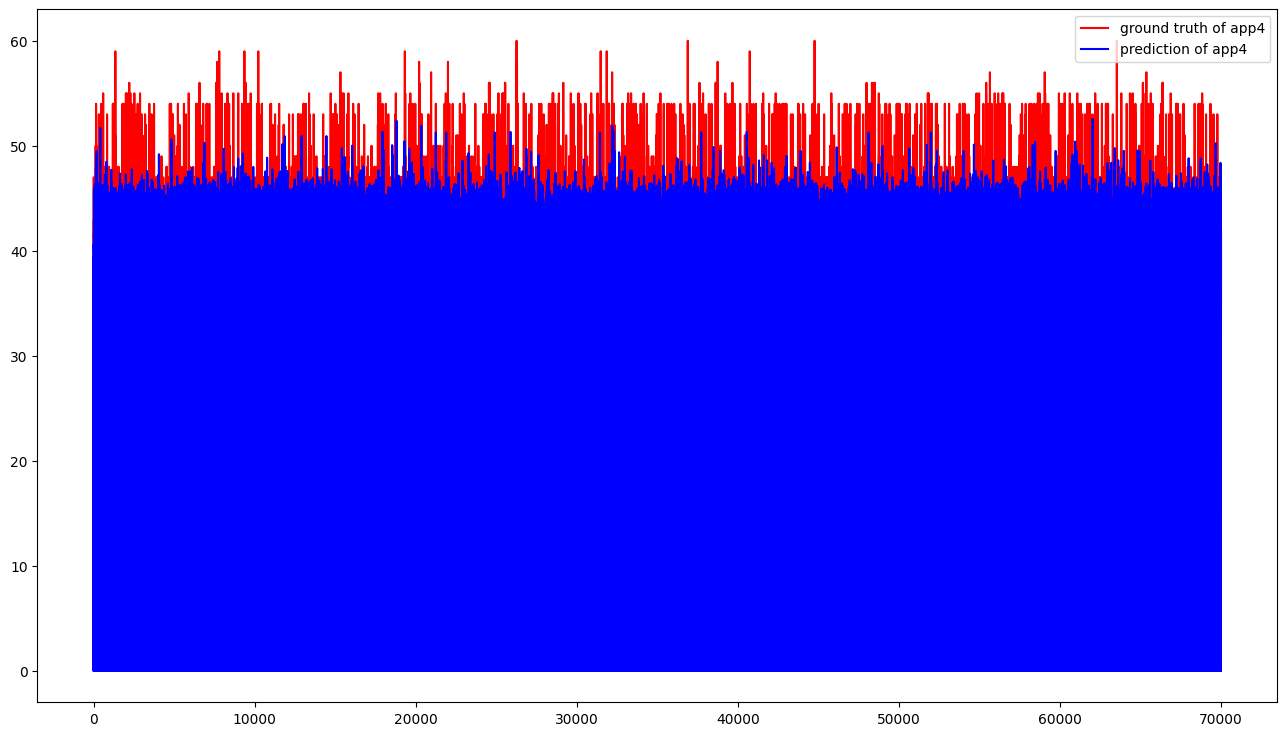

f1_energy_base: [0.27647372]
mae: [16.19746576]
ane: 0.8087542156114842


In [116]:
tester(save_dir =  model_save_dir4, app_num = 4) # sau chuẩn hóa và weighted loss

In [119]:
trainer(save_dir = model_save_dir5, app_num = 5, epochs = 20)

100%|██████████| 10287/10287 [03:17<00:00, 52.17it/s]


EPOCH: 1, average train loss: 0.8089371687587064


100%|██████████| 274/274 [00:02<00:00, 111.68it/s]


EPOCH: 1, average eval loss: 0.6075038771686574


100%|██████████| 10287/10287 [03:16<00:00, 52.33it/s]


...

EPOCH: 19, average eval loss: 0.33067943169722624


100%|██████████| 10287/10287 [03:33<00:00, 48.18it/s]


EPOCH: 20, average train loss: 0.29146823976085745


100%|██████████| 274/274 [00:02<00:00, 102.07it/s]

EPOCH: 20, average eval loss: 0.2863628508138171
Done training model for appliance 5


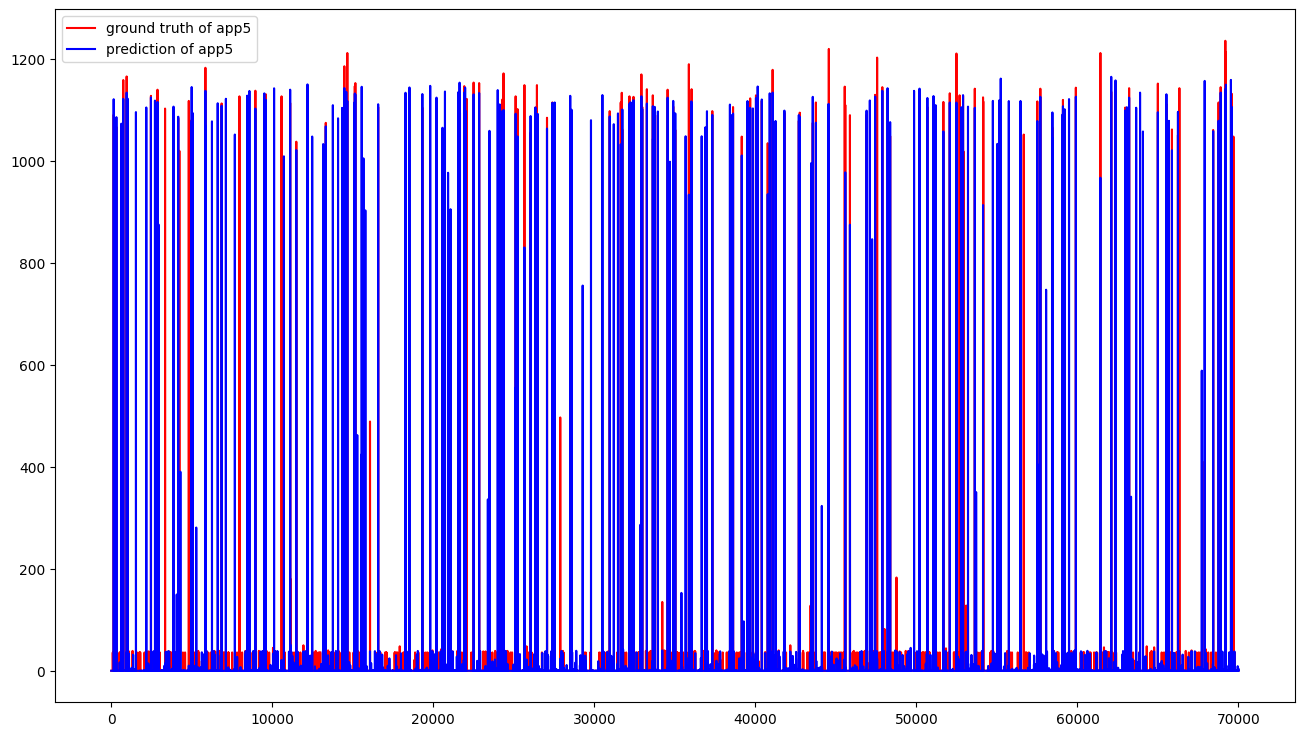

f1_energy_base: [0.61998955]
mae: [2.18988747]
ane: 0.3219818764130403


In [120]:
tester(save_dir = model_save_dir5, app_num = 5)

# Chú ý

Ở 1 số thiết bị kết quả predict rất tệ có thể nguyên do là tôi đã chuẩn hóa mỗi data mà không chuẩn hóa target gây ra mất cân bằng gradient, ngoài ra đối với các thiết bị như lò vi sóng thời gian off rất nhiều nên nếu dùng hàm loss mae hoặc mse thì model cứ đoán là 0 để an toàn nên có thể sẽ cần đổi hàm loss

Đối với 1 số thiết bị trong có vẻ hội tụ ngay từ các epoch đầu là vì giá trị khởi tạo ban đầu của các trọng số trong pytorch là bé cộng thêm việc chuẩn hóa input đầu vào theo z score nên đầu ra sẽ rất bé, trùng khớp với các thiết bị thường có thời gian OFF là nhiều thành ra model nghĩ là nó đã đúng và lười đi thêm 

In [39]:
train_set = np.load(train_npy_dir, mmap_mode='r')
train_target = train_set[:,-9:]

In [45]:
app_mean = train_target.mean(axis = 0)
app_mean

array([35.48838   , 17.604769  , 60.652378  ,  4.147716  ,  3.0918918 ,
        1.344885  ,  1.8039236 , 22.396675  ,  0.48135948], dtype=float32)

In [48]:
app_std = train_target.std(axis = 0)
app_std

array([ 43.676197 , 170.866    , 346.2078   ,  13.043402 ,  57.37543  ,
        35.23149  ,   5.1495433, 244.4293   ,   5.8274794], dtype=float32)

In [20]:
trainer(epochs = 10, save_dir = model_save_dir6, app_num = 6, lr = 5e-4, weight_factor = 50, weight_factor_off = 1.0, threshold_watt = 10.0)

100%|██████████| 21497/21497 [07:10<00:00, 49.94it/s]


EPOCH: 1, average train loss: 0.0154577044729891


100%|██████████| 80/80 [00:00<00:00, 94.62it/s]


EPOCH: 1, average eval loss: 0.012445586735702818


100%|██████████| 21497/21497 [07:46<00:00, 46.10it/s]


...

EPOCH: 9, average eval loss: 0.010231276584363513


100%|██████████| 21497/21497 [06:47<00:00, 52.80it/s]


EPOCH: 10, average train loss: 0.013551053662199433


100%|██████████| 80/80 [00:00<00:00, 99.62it/s]

EPOCH: 10, average eval loss: 0.014831997291776134
Done training model for appliance 6


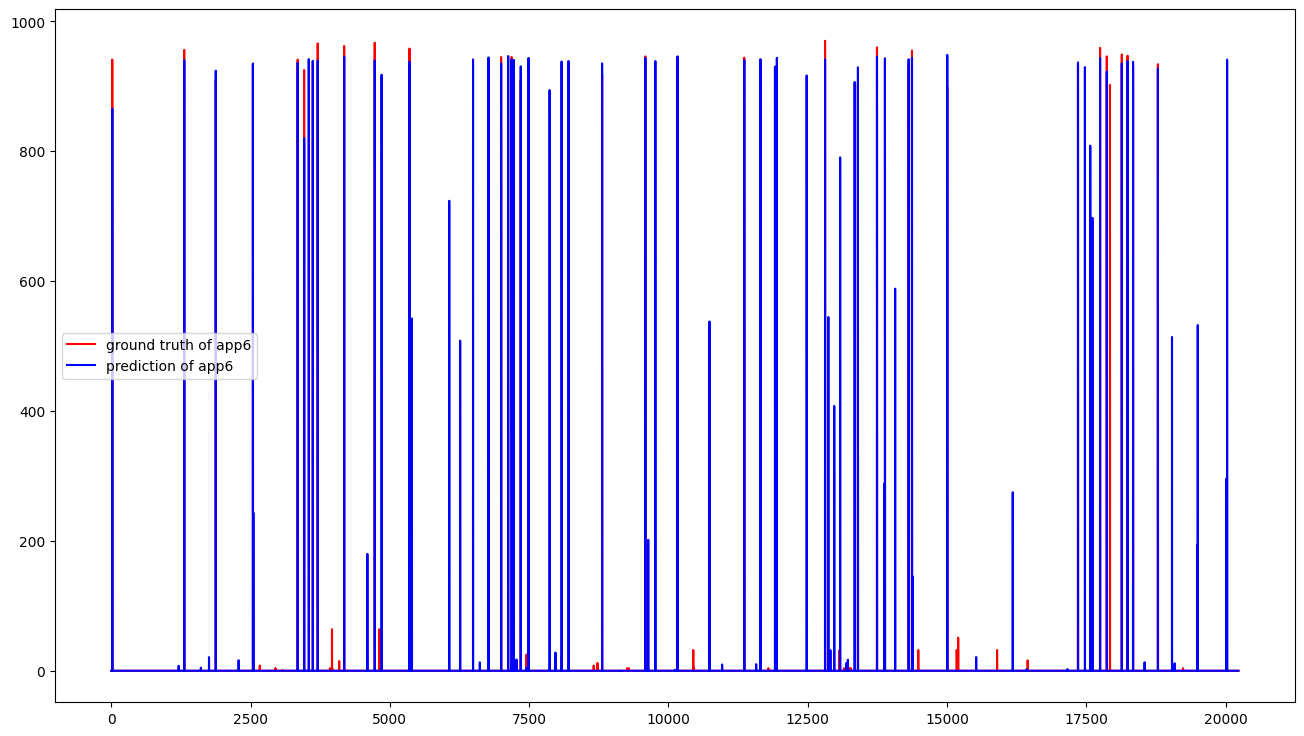

f1_energy_base: [0.69967097]
mae: [1.33930029]
ane: 0.4123458752785662


In [21]:
tester(save_dir = model_save_dir6, app_num = 6)

In [71]:
trainer(epochs = 20, save_dir = model_save_dir7, app_num = 7, lr = 1e-3, weight_factor = 100, weight_factor_off = 1.0, threshold_watt = 8.0)

100%|██████████| 21497/21497 [06:45<00:00, 53.06it/s]


EPOCH: 1, average train loss: 0.017307241081144082


100%|██████████| 80/80 [00:00<00:00, 85.00it/s]


EPOCH: 1, average eval loss: 0.018035984702873976


100%|██████████| 21497/21497 [07:09<00:00, 50.07it/s]


EPOCH: 2, average train loss: 0.016798839004584766


100%|██████████| 80/80 [00:00<00:00, 93.79it/s]


EPOCH: 2, average eval loss: 0.016281382739543916


  4%|▍         | 898/21497 [00:18<06:54, 49.64it/s]


KeyboardInterrupt: 

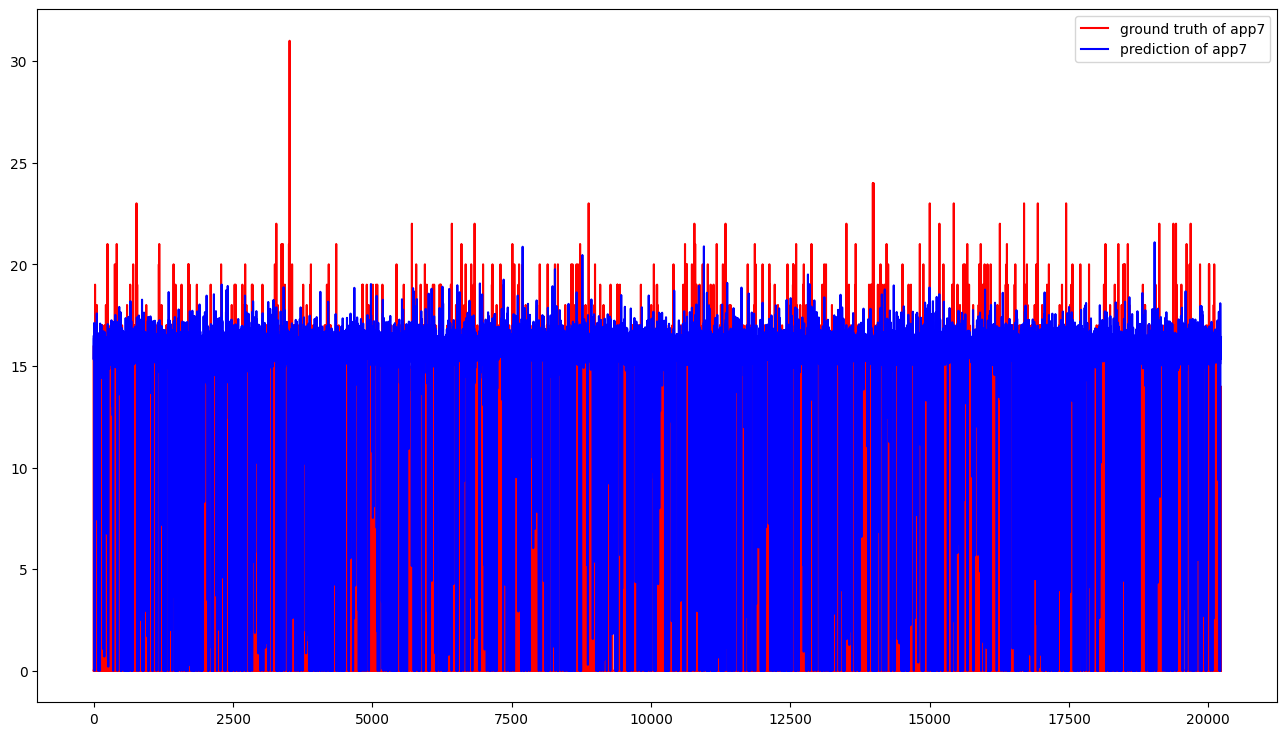

f1_energy_base: [0.19046092]
mae: [13.72494387]
ane: 0.8902729392924638


In [72]:
tester(model_save_dir7, app_num = 7)

In [24]:
trainer(epochs = 20, save_dir = model_save_dir8, app_num = 8)

100%|██████████| 10287/10287 [03:10<00:00, 53.93it/s]


EPOCH: 1, average train loss: 0.8881217907068912


100%|██████████| 274/274 [00:02<00:00, 115.55it/s]


EPOCH: 1, average eval loss: 0.210541976713295


100%|██████████| 10287/10287 [03:09<00:00, 54.20it/s]


...

EPOCH: 19, average eval loss: 0.1260189914159871


100%|██████████| 10287/10287 [04:15<00:00, 40.19it/s]


EPOCH: 20, average train loss: 0.13856691339905727


100%|██████████| 274/274 [00:03<00:00, 70.31it/s]

EPOCH: 20, average eval loss: 0.13792690288168838
Done training model for appliance 8


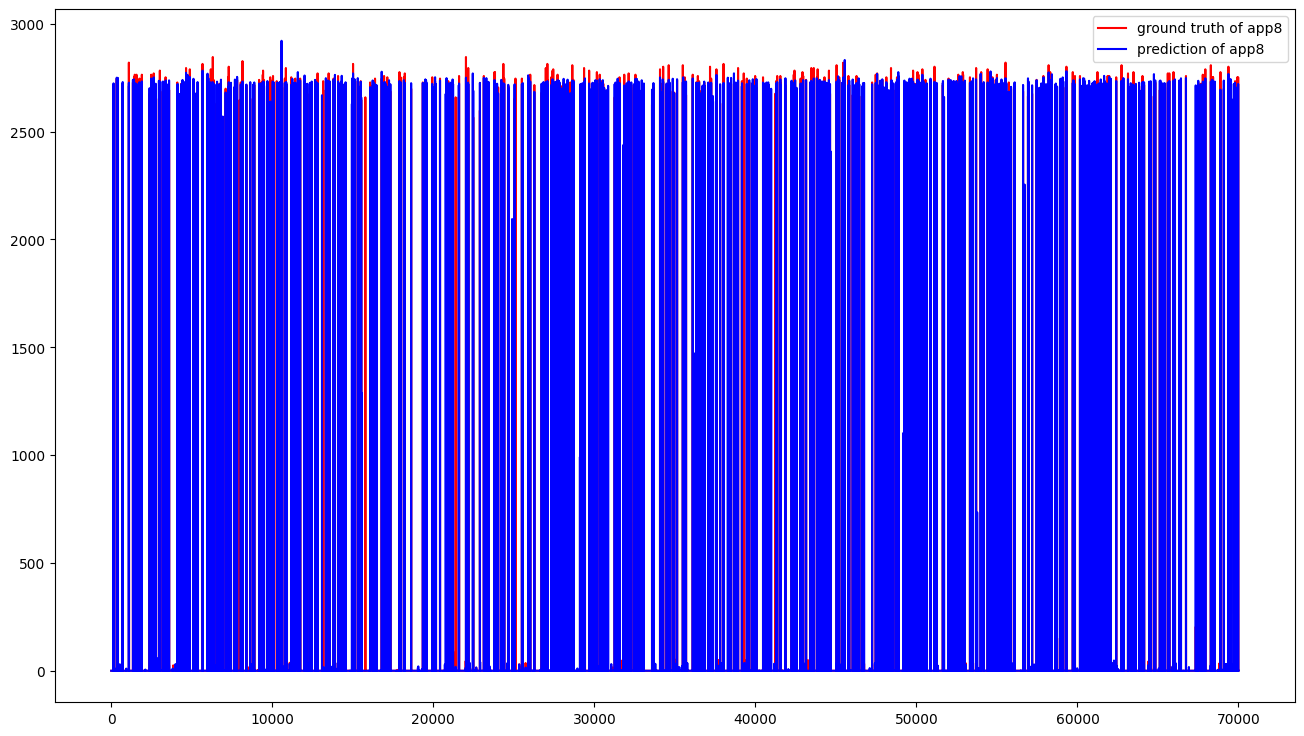

f1_energy_base: [0.90487122]
mae: [4.17455491]
ane: 0.1190687082205154


In [28]:
tester(save_dir = model_save_dir8, app_num = 8)

# App 4, 6 và 7 bị mean collapse
bởi vì thiết bị 4,6,7 có thời gian on ít hơn hẳn các khoảng thời gian off nên nếu để weight thấp thầm 15 thì lấy mean ra loss cũng không bị quá cao nên model lười cứ đoán mean

In [18]:
trainer(epochs = 20, save_dir = model_save_dir9, app_num = 9, lr = 5e-4, weight_factor = 170, weight_factor_off = 1.0, threshold_watt = 10.0)

100%|██████████| 21497/21497 [11:55<00:00, 30.03it/s]


EPOCH: 1, average train loss: 0.0842384567781718


100%|██████████| 80/80 [00:01<00:00, 69.88it/s]


EPOCH: 1, average eval loss: 0.06848519236664288


100%|██████████| 21497/21497 [06:42<00:00, 53.39it/s]


...

EPOCH: 19, average eval loss: 0.022632930289546493


100%|██████████| 21497/21497 [06:59<00:00, 51.19it/s]


EPOCH: 20, average train loss: 0.016853985241581222


100%|██████████| 80/80 [00:00<00:00, 96.22it/s]


EPOCH: 20, average eval loss: 0.02083261641491845
Done training model for appliance 9


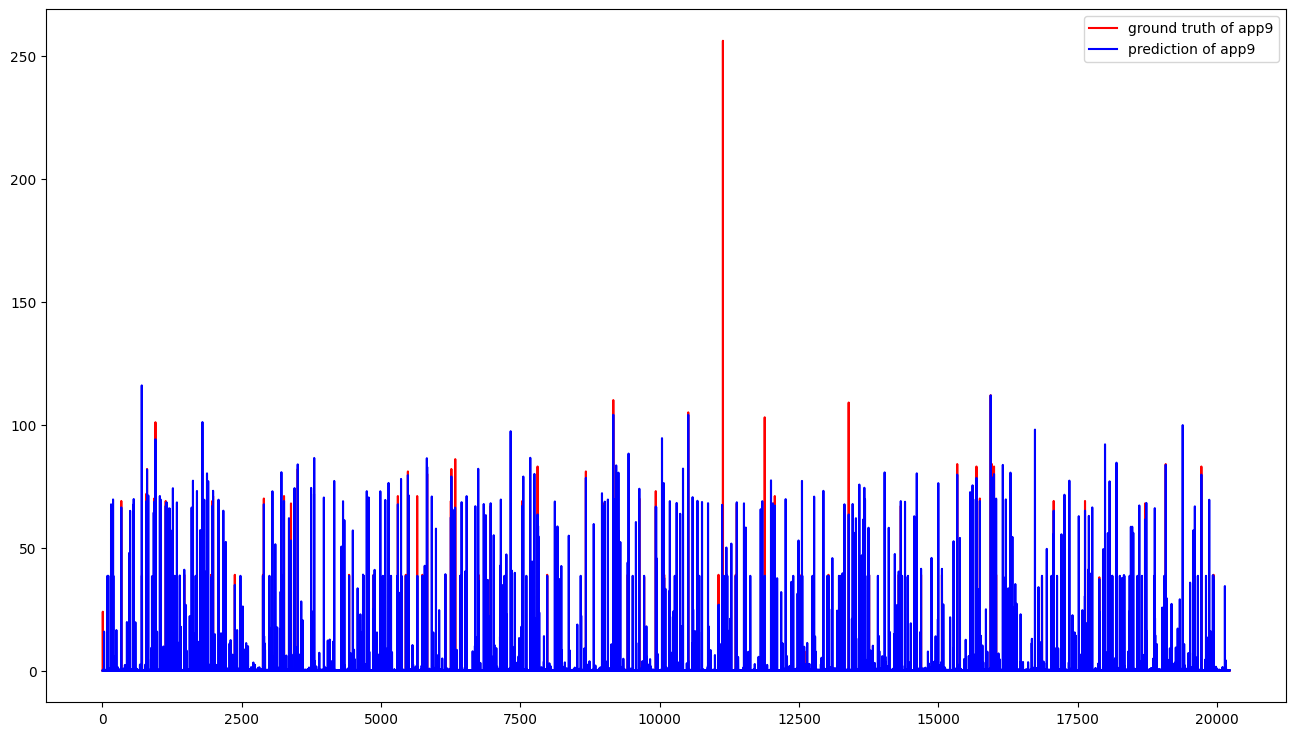

f1_energy_base: [0.30626073]
mae: [1.06294697]
ane: 0.7840924812770411


In [19]:
tester(save_dir = model_save_dir9, app_num = 9)

In [22]:
0.799 + 0.41014567 + 0.77369451 + 0.27647372 + 0.61998955 + 0.69967097 + 0.19046092 + 0.90487122 + 0.30626073

4.98056729

1 3 8 5 2

In [1]:
0.799 + 0.41014567 + 0.77369451 + 0.61998955 + 0.90487122

3.5077009500000003

In [2]:
3.5077009500000003 / 5

0.70154019